# Lab 6: Redes Neuronales Convolucionales (CNN) aplicadas a MNIST

En los laboratorios anteriores construimos **Perceptrones Multicapa (MLP)** que aplanan la imagen de 28×28 píxeles en un vector de 784 elementos para procesarla. Eso funciona, pero **ignora completamente la estructura espacial** de la imagen: qué píxeles están cerca de otros.

Las **Redes Neuronales Convolucionales (CNN)** fueron diseñadas específicamente para trabajar con datos que tienen estructura espacial (imágenes, señales, texto). En lugar de conectar cada píxel con cada neurona (conexiones densas), aplican pequeños filtros (**kernels**) que se deslizan sobre la imagen detectando patrones locales: bordes, esquinas, texturas, formas.

### ¿Por qué CNNs en lugar de MLPs para imágenes?

| Aspecto | MLP | CNN |
|---|---|---|
| Estructura de entrada | Vector 1-D (aplanado) | Tensor 2-D/3-D (original) |
| Tipo de conexión | Densa (todos con todos) | Local (kernel deslizante) |
| Parámetros | Muchos (784→256: 200k params) | Pocos (compartidos por posición) |
| Invarianza traslacional | ✗ No | ✓ Sí |
| Jerarquía de características | ✗ No | ✓ Sí (bordes → formas → objetos) |

### Objetivos de aprendizaje

1. Entender por qué **no** se aplana la imagen al cargar datos para una CNN.
2. Construir la arquitectura CNN de la imagen adjunta desde cero en PyTorch.
3. Calcular con precisión las dimensiones del tensor en cada capa.
4. Entrenar y evaluar la CNN en MNIST.
5. Adaptar la arquitectura al **proyecto semestral** propio.

### Ruta del laboratorio

1. Setup y carga de MNIST (sin aplanar).
2. **Parte 1:** Construcción de la arquitectura CNN.
3. **Parte 2:** Entrenamiento y evaluación.
4. **Parte 3 (Taller):** Adaptación al proyecto semestral.

---
## Setup: Librerías y Configuración

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
np.random.seed(42)
sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


---
## 1) Carga del Dataset MNIST

### Diferencia clave respecto a los MLPs anteriores

En los laboratorios de MLP (Lab 3 y Lab 4), el `transform` incluía `transforms.Lambda(lambda x: x.view(-1))` o simplemente confiábamos en que la primera capa `nn.Linear(784, ...)` recibía el tensor ya aplanado.

**En este laboratorio NO aplanamos la imagen.** El motivo es fundamental:

- Una **CNN** espera tensores con estructura espacial: `[Batch, Canales, Alto, Ancho]`
- Para MNIST en escala de grises: `[Batch, 1, 28, 28]`
- El eje `1` representa 1 canal de color (escala de grises). Una imagen RGB tendría `3`.

Si aplanáramos la imagen a `[Batch, 784]`, las capas `nn.Conv2d` no sabrían cómo interpretarla y fallaría con un error de dimensiones.

**Regla de oro:** `nn.Linear` trabaja con vectores → aplana. `nn.Conv2d` trabaja con mapas 2D → **no aplanes**.

In [ ]:
# ── Transform: normalización estándar de MNIST. SIN aplanar. ────────────────
transform = transforms.Compose([
    transforms.ToTensor(),                        # → [1, 28, 28], valores en [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),   # media y std del dataset MNIST
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Verificar shape: debe ser [1, 28, 28], NO [784]
img, label = train_ds[0]
print(f"Shape de una imagen: {img.shape}   ← [Canales, Alto, Ancho]")
print(f"Label de ejemplo:    {label}")
print(f"Train: {len(train_ds):,} muestras | Test: {len(test_ds):,} muestras")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.7MB/s]

Shape de una imagen: torch.Size([1, 28, 28])   ← [Canales, Alto, Ancho]
Label de ejemplo:    5
Train: 60,000 muestras | Test: 10,000 muestras


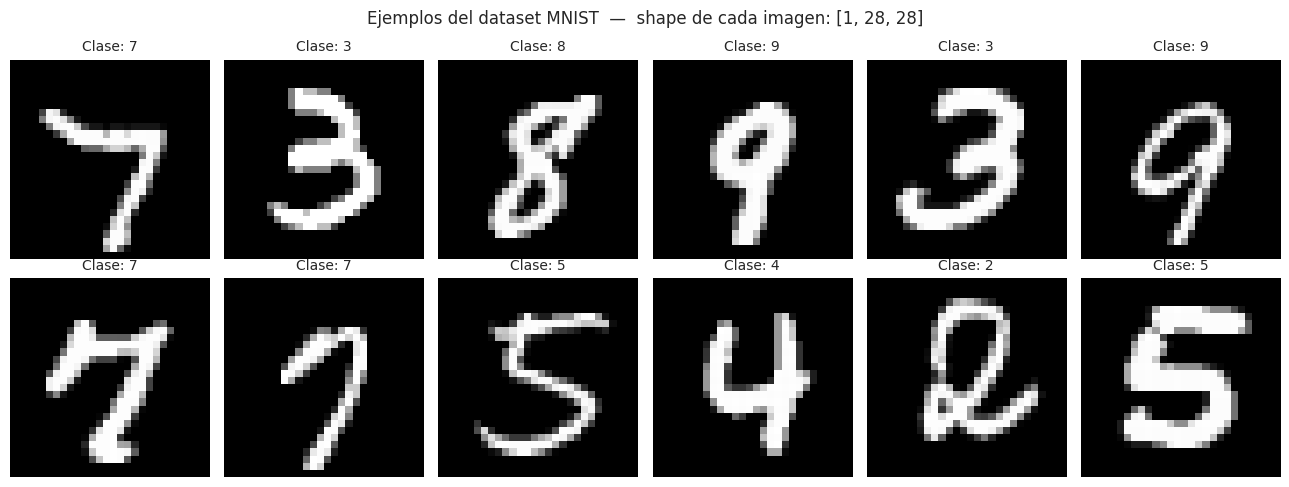

In [ ]:
# Visualización de algunos ejemplos del dataset
fig, axes = plt.subplots(2, 6, figsize=(13, 5))
idx = np.random.choice(len(train_ds), size=12, replace=False)

for ax, i in zip(axes.ravel(), idx):
    img, label = train_ds[i]
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Clase: {label}", fontsize=10)
    ax.axis("off")

plt.suptitle("Ejemplos del dataset MNIST  —  shape de cada imagen: [1, 28, 28]", fontsize=12)
plt.tight_layout()
plt.show()

---
## Exploración: ¿Qué hace un filtro convolucional?

Antes de construir la red completa, necesitamos entender el componente más fundamental de una CNN: **el filtro (o kernel)**.

### ¿Qué es un kernel?

Un kernel es una pequeña matriz de pesos (ej. 3×3) que se **desliza sobre la imagen** calculando el producto punto con cada región local. El resultado es un **mapa de características** (*feature map*) que resalta patrones específicos.

La operación en un punto $(i, j)$ del feature map es:

$$\text{FeatureMap}[i, j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \text{Imagen}[i+m,\; j+n] \cdot \text{Kernel}[m, n]$$

### Los 4 filtros de la imagen

Cada filtro detecta un tipo distinto de **borde**. Los bordes son los rasgos visuales más básicos, y los primeros que aprende una CNN en sus capas iniciales.

| Filtro | Patrón | Qué detecta |
|---|---|---|
| **Filter 1** | Fila media `+1`, fila superior `-1` | Bordes **horizontales** (oscuro → claro, arriba→abajo) |
| **Filter 2** | Columna central `+1`, columna izquierda `-1` | Bordes **verticales** (oscuro → claro, izquierda→derecha) |
| **Filter 3** | Fila media `+1`, fila inferior `-1` | Bordes **horizontales** invertidos (claro → oscuro) |
| **Filter 4** | Columna central `+1`, columna derecha `-1` | Bordes **verticales** invertidos |

> **Clave conceptual:** En una CNN entrenada con backpropagation, la red **aprende** estos pesos automáticamente. No los programamos a mano. Aquí los reproducimos manualmente para ver el mecanismo antes de que la red los descubra sola.

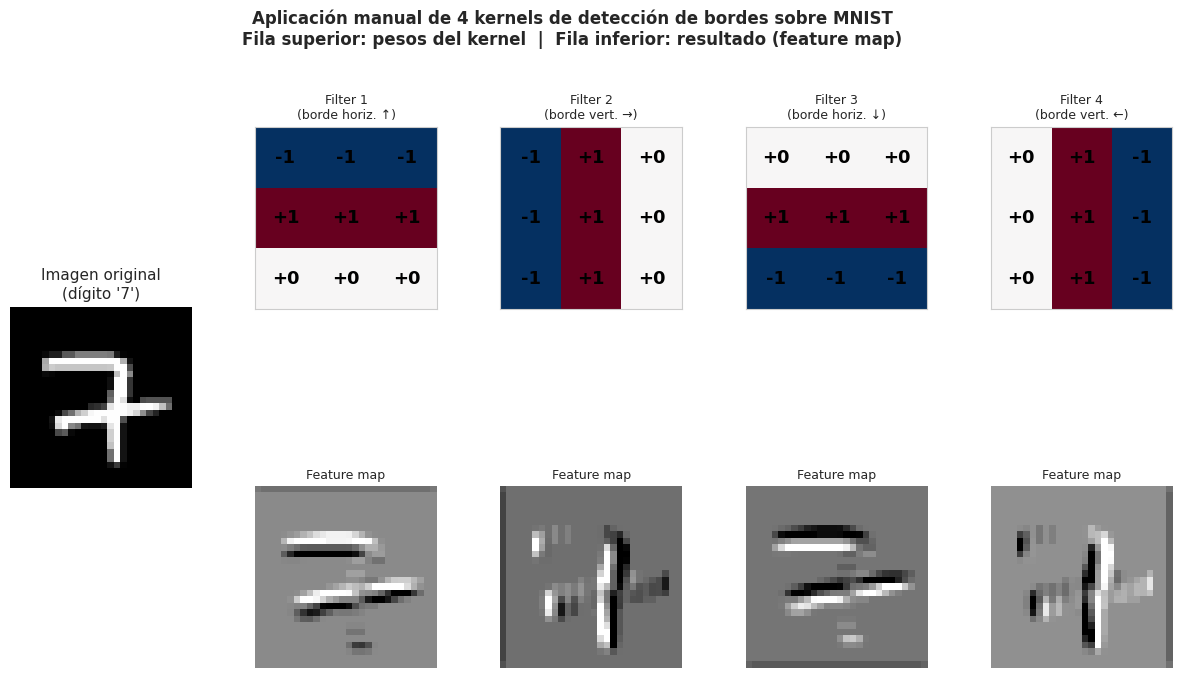

Observaciones:
  • Las zonas BLANCAS en el feature map indican bordes donde el filtro activó fuerte.
  • Las zonas NEGRAS son regiones sin el patrón buscado (activación ≈ 0 o negativa).
  • Cada filtro 'ilumina' un tipo distinto de borde en la misma imagen.
  • En una CNN, DOCENAS de estos filtros aprenden en paralelo por capa.


In [ ]:
import torch.nn.functional as F

# ── Los 4 filtros de la imagen de referencia (kernels 3×3) ───────────────────
kernels = {
    "Filter 1\n(borde horiz. ↑)": torch.tensor([
        [-1., -1., -1.],
        [ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
    ]),
    "Filter 2\n(borde vert. →)": torch.tensor([
        [-1.,  1.,  0.],
        [-1.,  1.,  0.],
        [-1.,  1.,  0.],
    ]),
    "Filter 3\n(borde horiz. ↓)": torch.tensor([
        [ 0.,  0.,  0.],
        [ 1.,  1.,  1.],
        [-1., -1., -1.],
    ]),
    "Filter 4\n(borde vert. ←)": torch.tensor([
        [ 0.,  1., -1.],
        [ 0.,  1., -1.],
        [ 0.,  1., -1.],
    ]),
}

# ── Tomar una imagen de MNIST como ejemplo ────────────────────────────────────
# Buscamos un dígito "7" para que se parezca al de la imagen de referencia
target_digit = 7
indices_7 = [i for i in range(len(train_ds)) if train_ds[i][1] == target_digit]
sample_img, sample_label = train_ds[indices_7[2]]   # tercera muestra de ese dígito

# Forma para aplicar F.conv2d: [1, 1, H, W]  (batch=1, canal=1)
img_4d = sample_img.unsqueeze(0)   # [1, 1, 28, 28]

# ── Aplicar cada filtro con F.conv2d ─────────────────────────────────────────
feature_maps = {}
for name, kernel in kernels.items():
    # kernel debe tener forma [out_channels, in_channels, kH, kW]
    k = kernel.view(1, 1, 3, 3)
    # padding=1 para mantener el tamaño espacial (28×28)
    fmap = F.conv2d(img_4d, k, padding=1)          # [1, 1, 28, 28]
    feature_maps[name] = fmap.squeeze().numpy()     # [28, 28]

# ── Visualización ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.4, wspace=0.35)

# — Imagen original (columna izquierda, ocupa las 2 filas) —
ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(sample_img.squeeze().numpy(), cmap="gray")
ax_orig.set_title(f"Imagen original\n(dígito '{sample_label}')", fontsize=11)
ax_orig.axis("off")

# — Kernels (fila superior) y feature maps (fila inferior) —
for col, (name, kernel) in enumerate(kernels.items(), start=1):
    # Kernel como heatmap
    ax_k = fig.add_subplot(gs[0, col])
    im = ax_k.imshow(kernel.numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
    ax_k.set_title(name, fontsize=9)
    for (r, c), val in np.ndenumerate(kernel.numpy()):
        ax_k.text(c, r, f"{int(val):+d}", ha="center", va="center",
                  fontsize=13, color="black", fontweight="bold")
    ax_k.set_xticks([])
    ax_k.set_yticks([])

    # Feature map resultante
    ax_f = fig.add_subplot(gs[1, col])
    fmap = feature_maps[name]
    ax_f.imshow(fmap, cmap="gray",
                vmin=np.percentile(fmap, 2), vmax=np.percentile(fmap, 98))
    ax_f.set_title("Feature map", fontsize=9)
    ax_f.axis("off")

fig.suptitle(
    "Aplicación manual de 4 kernels de detección de bordes sobre MNIST\n"
    "Fila superior: pesos del kernel  |  Fila inferior: resultado (feature map)",
    fontsize=12, fontweight="bold"
)
plt.show()

# ── Resumen de lo que está ocurriendo ─────────────────────────────────────────
print("Observaciones:")
print("  • Las zonas BLANCAS en el feature map indican bordes donde el filtro activó fuerte.")
print("  • Las zonas NEGRAS son regiones sin el patrón buscado (activación ≈ 0 o negativa).")
print("  • Cada filtro 'ilumina' un tipo distinto de borde en la misma imagen.")
print("  • En una CNN, DOCENAS de estos filtros aprenden en paralelo por capa.")

---
## Parte 1: Construcción de la Arquitectura CNN

### La arquitectura de la imagen

La red que implementaremos tiene **3 bloques convolucionales** seguidos de **2 capas fully-connected**:

```
Entrada [B, 1, 28, 28]
    │
    ├─ Bloque 1 (verde)
    │   Conv2d(1→32, k=3, padding=1)   →  [B, 32, 28, 28]
    │   BatchNorm2d(32)
    │   ReLU
    │   MaxPool2d(k=3, stride=2)       →  [B, 32, 13, 13]
    │
    ├─ Bloque 2 (amarillo)
    │   Conv2d(32→64, k=3, padding=1)  →  [B, 64, 13, 13]
    │   BatchNorm2d(64)
    │   ReLU
    │   MaxPool2d(k=3, stride=2)       →  [B, 64, 6, 6]
    │
    ├─ Bloque 3 (rojo)
    │   Conv2d(64→128, k=3, padding=1) →  [B, 128, 6, 6]
    │   BatchNorm2d(128)
    │   ReLU
    │   MaxPool2d(k=3, stride=2)       →  [B, 128, 2, 2]
    │
    ├─ Flatten                         →  [B, 512]
    │
    ├─ Linear(512 → 256) + ReLU        →  [B, 256]
    └─ Linear(256 → 10)                →  [B, 10]  ← logits (sin softmax)
```

**Nota sobre `BatchNorm2d`:** Normaliza la activación de cada canal a lo largo del batch, estabilizando el entrenamiento y actuando como regularizador suave. Se aplica *antes* de la activación ReLU.

### Cálculo de dimensiones paso a paso

Para entender cuántas neuronas ponemos en la primera capa `nn.Linear`, debemos rastrear matemáticamente cómo cambia el tensor en cada operación.

**Fórmulas generales:**

Para una capa convolucional con `padding = p`, `kernel = k`, `stride = s = 1`:
$$H_{out} = \left\lfloor \frac{H_{in} + 2p - k}{s} \right\rfloor + 1$$

Con `padding=1` y `kernel=3`: $H_{out} = H_{in}$ (el tamaño **no cambia**).

Para MaxPool con `kernel = k`, `stride = s`:
$$H_{out} = \left\lfloor \frac{H_{in} - k}{s} \right\rfloor + 1$$

---

**Seguimiento del tensor — MNIST (28×28):**

| Capa | Fórmula | H×W resultado | Canales | Tensor |
|---|---|---|---|---|
| Entrada | — | 28 × 28 | 1 | [B, 1, 28, 28] |
| Conv1 (k=3, p=1) | $28 + 2(1) - 3 + 1 = 28$ | 28 × 28 | 32 | [B, 32, 28, 28] |
| MaxPool1 (k=3, s=2) | $\lfloor(28-3)/2\rfloor + 1 = 13$ | 13 × 13 | 32 | [B, 32, 13, 13] |
| Conv2 (k=3, p=1) | $13 + 2(1) - 3 + 1 = 13$ | 13 × 13 | 64 | [B, 64, 13, 13] |
| MaxPool2 (k=3, s=2) | $\lfloor(13-3)/2\rfloor + 1 = 6$ | 6 × 6 | 64 | [B, 64, 6, 6] |
| Conv3 (k=3, p=1) | $6 + 2(1) - 3 + 1 = 6$ | 6 × 6 | 128 | [B, 128, 6, 6] |
| MaxPool3 (k=3, s=2) | $\lfloor(6-3)/2\rfloor + 1 = 2$ | 2 × 2 | 128 | [B, 128, 2, 2] |
| **Flatten** | $128 \times 2 \times 2$ | — | — | **[B, 512]** |

**Conclusión:** La primera capa lineal debe recibir exactamente **512 features** → `nn.Linear(512, 256)`.

> 💡 **Tip:** Si cambias el tamaño de entrada (e.g. imágenes de tu proyecto de 64×64), deberás recalcular este número. La sección 3 de este laboratorio incluye un script de debugging para hacerlo automáticamente.

In [ ]:
class CNN_MNIST(nn.Module):
    """
    CNN de 3 bloques convolucionales para clasificación de dígitos MNIST.

    Arquitectura (según imagen de referencia):
        Bloque 1: Conv(1→32)  + BN + ReLU + MaxPool
        Bloque 2: Conv(32→64) + BN + ReLU + MaxPool
        Bloque 3: Conv(64→128)+ BN + ReLU + MaxPool
        Clasificador: Linear(512→256) + ReLU + Linear(256→10)
    """

    def __init__(self):
        super().__init__()

        # ── Bloque 1 (verde en la imagen) ───────────────────────────────────
        # Entrada: [B, 1, 28, 28]   →   Salida tras pool: [B, 32, 13, 13]
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── Bloque 2 (amarillo en la imagen) ────────────────────────────────
        # Entrada: [B, 32, 13, 13]  →   Salida tras pool: [B, 64, 6, 6]
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── Bloque 3 (rojo en la imagen) ─────────────────────────────────────
        # Entrada: [B, 64, 6, 6]    →   Salida tras pool: [B, 128, 2, 2]
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # ── Clasificador fully-connected ─────────────────────────────────────
        # Después del flatten: 128 canales × 2 × 2 = 512 features
        self.classifier = nn.Sequential(
            nn.Flatten(),             # [B, 128, 2, 2] → [B, 512]
            nn.Linear(512, 256),      # fc 256
            nn.ReLU(),
            nn.Linear(256, 10),       # fc 10  (una neurona por clase de MNIST)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x    # logits crudos; CrossEntropyLoss aplica softmax internamente

In [ ]:
# Instanciar el modelo y moverlo al dispositivo disponible
model = CNN_MNIST().to(device)
print(model)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal de parámetros entrenables: {total_params:,}")

# Verificación rápida de dimensiones: pasar un tensor de prueba
dummy = torch.zeros(1, 1, 28, 28).to(device)   # un batch de 1 imagen
with torch.no_grad():
    out = model(dummy)
print(f"\nShape de entrada:  {dummy.shape}")
print(f"Shape de salida:   {out.shape}   ← [Batch, 10 clases]")

CNN_MNIST(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=512, out_featu

---
## Parte 2: Entrenamiento y Evaluación

### Configuración del entrenamiento

Utilizamos:
- **`nn.CrossEntropyLoss`**: Combina `LogSoftmax` + `NLLLoss` internamente. Ideal para clasificación multiclase. Espera **logits crudos** (no apliques softmax antes).
- **Optimizador `Adam`**: Adapta la tasa de aprendizaje por parámetro. Generalmente converge más rápido que SGD vanilla. `lr=1e-3` es un buen punto de partida.

> **Recordatorio del ciclo de entrenamiento** (Lab 5):
> 1. `optimizer.zero_grad()` — limpiar gradientes acumulados
> 2. `output = model(x)` — forward pass
> 3. `loss = criterion(output, y)` — calcular pérdida
> 4. `loss.backward()` — calcular gradientes (backprop)
> 5. `optimizer.step()` — actualizar pesos

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una época completa de entrenamiento. Retorna loss promedio y accuracy."""
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # 1. limpiar gradientes
        logits = model(images)          # 2. forward pass
        loss = criterion(logits, labels) # 3. calcular pérdida
        loss.backward()                 # 4. backpropagation
        optimizer.step()                # 5. actualizar pesos

        total_loss    += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evalúa el modelo en un DataLoader. Sin cálculo de gradientes."""
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss    += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

In [ ]:
# ── Hiperparámetros ──────────────────────────────────────────────────────────
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

# Reiniciar modelo para entrenamiento limpio
model = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ── Bucle de entrenamiento ───────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"{'Época':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>8.2%}")

print("\nEntrenamiento completado.")

 Época | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     0.1237 |   96.39% |   0.0469 |   98.43%
     2 |     0.0358 |   98.85% |   0.0254 |   99.14%
     3 |     0.0256 |   99.22% |   0.0286 |   99.11%
     4 |     0.0226 |   99.30% |   0.0259 |   99.04%
     5 |     0.0172 |   99.46% |   0.0252 |   99.23%

Entrenamiento completado.


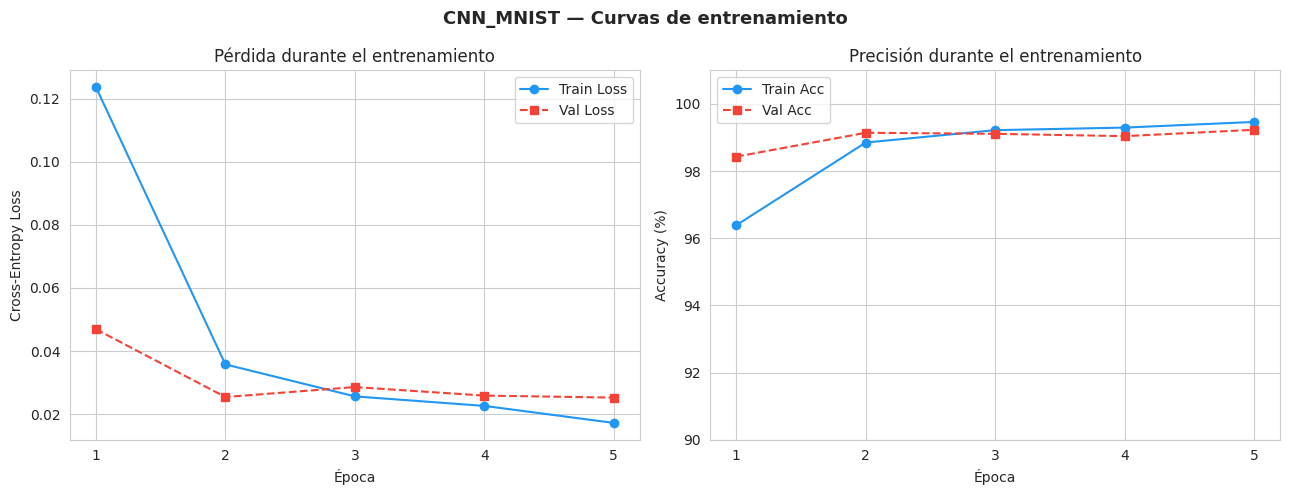


Accuracy final en test: 99.2300%


In [ ]:
# ── Gráficos de Loss y Accuracy ──────────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# — Loss —
ax1.plot(epochs_range, history["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax1.plot(epochs_range, history["val_loss"],   "s--", label="Val Loss",   color="#F44336")
ax1.set_xlabel("Época")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Pérdida durante el entrenamiento")
ax1.legend()
ax1.set_xticks(list(epochs_range))

# — Accuracy —
ax2.plot(epochs_range, [a * 100 for a in history["train_acc"]], "o-", label="Train Acc", color="#2196F3")
ax2.plot(epochs_range, [a * 100 for a in history["val_acc"]],   "s--", label="Val Acc",   color="#F44336")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Precisión durante el entrenamiento")
ax2.legend()
ax2.set_xticks(list(epochs_range))
ax2.set_ylim([90, 101])

plt.suptitle("CNN_MNIST — Curvas de entrenamiento", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Accuracy final en test
final_val_loss, final_val_acc = evaluate(model, test_loader, criterion, device)
print(f"\nAccuracy final en test: {final_val_acc:.4%}")

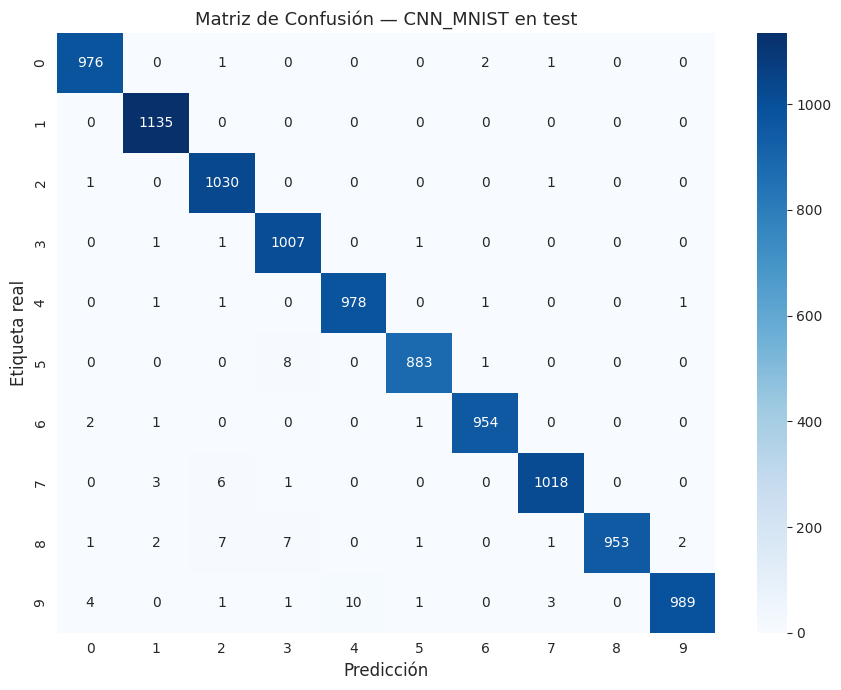

  Clase 0: 4 errores
  Clase 1: 0 errores
  Clase 2: 2 errores
  Clase 3: 3 errores
  Clase 4: 4 errores
  Clase 5: 9 errores
  Clase 6: 4 errores
  Clase 7: 10 errores
  Clase 8: 21 errores
  Clase 9: 20 errores


In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=range(10), yticklabels=range(10),
    ax=ax
)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_title("Matriz de Confusión — CNN_MNIST en test", fontsize=13)
plt.tight_layout()
plt.show()

# Clases con más errores
errors_per_class = cm.sum(axis=1) - cm.diagonal()
for cls, err in enumerate(errors_per_class):
    print(f"  Clase {cls}: {err} errores")

---
## Parte 3: Aplicación al Proyecto

El objetivo es que tomes la red `CNN_MNIST` que acabas de construir y la **adaptes a tu propio dataset** de proyecto. La CNN que construiste es un excelente punto de partida; solo necesitas ajustar tres aspectos clave:

1. **Canales de entrada** (`in_channels`): ¿tu dataset usa imágenes RGB (3 canales) o escala de grises (1 canal)?
2. **Capa de salida** (`out_features`): ¿cuántas clases tiene tu problema?
3. **Dimensiones del tensor aplanado**: ¿qué tamaño tienen realmente tus imágenes?

Las siguientes subsecciones te guían por cada uno de estos ajustes.

### 3.1 Ajuste de Canales de Entrada

**¿Cuántos canales tiene una imagen?**

| Tipo de imagen | Canales | `in_channels` |
|---|---|---|
| Escala de grises | 1 | `1` |
| RGB (color) | 3 | `3` |
| RGBA (con transparencia) | 4 | `4` |
| Imagen médica multiespectral | N | `N` |

En `CNN_MNIST` usamos `in_channels=1` porque MNIST es en escala de grises `[B, 1, 28, 28]`.
Si tu dataset contiene imágenes **a color** (RGB), el tensor de entrada tendrá forma `[B, 3, H, W]` y debes cambiar únicamente la **primera convolución**.

> **Importante:** Solo la primera capa `Conv2d` depende del número de canales de entrada. Las capas posteriores conectan canales de salida con canales de entrada de la siguiente capa → las demás **no cambian**.

In [ ]:
# ── TODO 3.1: Ajusta este bloque a las características de tu dataset ──────────

# Define las características de TU dataset aquí:
MY_IN_CHANNELS = 3        # TODO: cambia a 1 (gris), 3 (RGB), etc.
MY_NUM_CLASSES = 5        # TODO: cambia al número de clases de tu problema
MY_IMAGE_H     = 64       # TODO: alto de tus imágenes en píxeles
MY_IMAGE_W     = 64       # TODO: ancho de tus imágenes en píxeles

# Imprime un resumen del dataset de tu proyecto
print("─── Configuración de mi proyecto ───────────────────────────────────")
print(f"  Canales de entrada : {MY_IN_CHANNELS}  ({'RGB' if MY_IN_CHANNELS == 3 else 'Escala de grises' if MY_IN_CHANNELS == 1 else 'Custom'})")
print(f"  Número de clases   : {MY_NUM_CLASSES}")
print(f"  Tamaño de imágenes : {MY_IMAGE_H} × {MY_IMAGE_W}")
print(f"  Forma del tensor   : [Batch, {MY_IN_CHANNELS}, {MY_IMAGE_H}, {MY_IMAGE_W}]")
print("─────────────────────────────────────────────────────────────────────")

─── Configuración de mi proyecto ───────────────────────────────────
  Canales de entrada : 3  (RGB)
  Número de clases   : 5
  Tamaño de imágenes : 64 × 64
  Forma del tensor   : [Batch, 3, 64, 64]
─────────────────────────────────────────────────────────────────────


### 3.2 Script de Diagnóstico de Dimensiones

**El error más frecuente al adaptar una CNN:** `RuntimeError: mat1 and mat2 shapes cannot be multiplied`.

Este error ocurre porque el número de features que llega al `nn.Linear` no coincide con el `in_features` declarado. Cambia el tamaño de imagen → cambia ese número.

**Solución: pasar un tensor ficticio (*dummy tensor*) por los bloques convolucionales antes de definir la capa linear.**

El siguiente script hace exactamente eso: construye los bloques convolucionales con los parámetros de **tu** dataset, pasa un tensor de prueba, y calcula automáticamente cuántas features entran al clasificador.

In [ ]:
def compute_flat_features(in_channels: int, image_h: int, image_w: int) -> int:
    """
    Calcula el número de features aplanadas que salen de los 3 bloques convolucionales.
    Útil para determinar el in_features del primer nn.Linear sin errores de shape.

    Parámetros
    ----------
    in_channels : canales de entrada de tu dataset (1=gris, 3=RGB, etc.)
    image_h     : alto de tus imágenes en píxeles
    image_w     : ancho de tus imágenes en píxeles

    Retorna
    -------
    int : número de features que llegarán a la primera capa lineal
    """
    # Construir solo la parte convolucional (idéntica a CNN_MNIST)
    feature_extractor = nn.Sequential(
        # Bloque 1
        nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        # Bloque 2
        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        # Bloque 3
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2),
        # Aplanar
        nn.Flatten(),
    )

    # Pasar un tensor de prueba de un solo ejemplo (batch_size=1)
    dummy = torch.zeros(1, in_channels, image_h, image_w)
    with torch.no_grad():
        out = feature_extractor(dummy)

    flat_features = out.shape[1]
    return flat_features, feature_extractor


# ── Diagnóstico con los valores de TU proyecto ───────────────────────────────
flat_features, _ = compute_flat_features(MY_IN_CHANNELS, MY_IMAGE_H, MY_IMAGE_W)

print("═" * 55)
print(" DIAGNÓSTICO DE DIMENSIONES")
print("═" * 55)
print(f" Entrada           : [{MY_IN_CHANNELS}, {MY_IMAGE_H}, {MY_IMAGE_W}]")
print(f" Features aplanadas: {flat_features}")
print(f" → Primera capa lineal debe ser: nn.Linear({flat_features}, 256)")
print("═" * 55)

═══════════════════════════════════════════════════════
 DIAGNÓSTICO DE DIMENSIONES
═══════════════════════════════════════════════════════
 Entrada           : [3, 64, 64]
 Features aplanadas: 6272
 → Primera capa lineal debe ser: nn.Linear(6272, 256)
═══════════════════════════════════════════════════════


---
## Conclusiones

En este laboratorio:

1. **Mantener la estructura espacial** de la imagen en el `DataLoader` (tensor `[B, C, H, W]`), sin aplanar, para que las capas convolucionales puedan aprovechar la información espacial.

2. **Rastrear matemáticamente las dimensiones** del tensor a través de convoluciones y maxpoolings, usando la fórmula $H_{out} = \lfloor (H_{in} - k) / s \rfloor + 1$ para identificar exactamente cuántas features entran al clasificador lineal.

3. **Implementar la arquitectura CNN** de la imagen de referencia en PyTorch con `nn.Conv2d`, `nn.BatchNorm2d`, `nn.ReLU` y `nn.MaxPool2d`, estructurada en bloques secuenciales.

4. **Entrenar y evaluar** la CNN usando el mismo ciclo `zero_grad → forward → loss → backward → step` que dominas del Lab 5, ahora sobre datos multidimensionales.

5. **Adaptar la red** a cualquier dataset ajustando `in_channels`, usando el script de diagnóstico de dimensiones para evitar errores de shape, y ajustando `num_classes` en la capa de salida.